<a href="https://colab.research.google.com/github/sargyri/Drop_Lev/blob/master/Applications/PNIPAM%20/Machine_learning/Microgels_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import re
import glob
import matplotlib.pyplot as plt
# from scipy.signal import  gaussian
from scipy.ndimage import filters
from scipy import optimize
from scipy.stats import linregress
from mpl_toolkits.mplot3d import Axes3D

import seaborn as sns

import scipy as sp
import scipy.interpolate

import time

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize
from matplotlib import cm
from google.colab import drive
from numpy.random import seed

from scipy.optimize import curve_fit

    def fit_cos_sin(tt, yy, omega):
        X = np.column_stack([np.ones_like(tt), np.cos(omega*tt), np.sin(omega*tt)])
        c, *_ = np.linalg.lstsq(X, yy, rcond=None)
        return c  # c0, c1, c2

    i = 0
    N = len(t)
    while i + win_len <= N:
        tt = t[i:i+win_len]
        AA = A[i:i+win_len]
        gg = gamma[i:i+win_len]

        cA = fit_cos_sin(tt, AA, omega)
        cg = fit_cos_sin(tt, gg, omega)

        A0, A_c1, A_c2 = cA
        g0, g_c1, g_c2 = cg

        DeltaA = np.hypot(A_c1, A_c2)
        Deltag = np.hypot(g_c1, g_c2)

        A_mean = np.mean(AA)
        if abs(A_mean) < 1e-12:
            i += step; continue
        eps = DeltaA / A_mean
        if eps <= 0 or not np.isfinite(eps):
            i += step; continue

        phiA = np.arctan2(A_c2, A_c1)
        phig = np.arctan2(g_c2, g_c1)
        delta = (phig - phiA + np.pi) % (2*np.pi) - np.pi

        factor = Deltag / eps
        E_storage = factor * np.cos(delta)
        E_loss = factor * np.sin(delta)

        Pi_mid = gamma_ref - np.mean(gg)

        results["Pi_mid"].append(Pi_mid)
        results["E_storage"].append(E_storage)
        results["E_loss"].append(E_loss)
        results["epsilon"].append(eps)

        i += step

    # convert lists to arrays
    for k in ["Pi_mid","E_storage","E_loss","epsilon"]:
        results[k] = np.asarray(results[k])

    return results

from scipy.signal import welch, csd, detrend


import numpy as np
from scipy.signal import welch, csd, detrend


In [ ]:

def fit_oscillation(x, y, damped=False, p0=None):
    """
    Fit oscillatory data with optional damping.

    Parameters
    ----------
    x : array-like
        Independent variable (e.g., time or area)
    y : array-like
        Dependent variable (e.g., gamma)
    damped : bool
        If True, include exponential decay factor
    p0 : list or None
        Initial guesses [y0, A, omega, phi] or [y0, A, k, omega, phi]

    Returns
    -------
    popt : array
        Fitted parameters
    y_fit : array
        Fitted values at x
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Define model
    if damped:
        def model(x, y0, A, k, omega, phi):
            return y0 + A * np.exp(-k*x) * np.cos(omega*x + phi)
        if p0 is None:
            y0_guess = np.mean(y)
            A_guess = (np.max(y)-np.min(y))/2
            k_guess = 0.1
            # Rough estimate of omega from FFT
            dt = np.mean(np.diff(x))
            freqs = np.fft.rfftfreq(len(x), dt)
            fft_vals = np.fft.rfft(y - np.mean(y))
            idx = np.argmax(np.abs(fft_vals[1:])) + 1
            omega_guess = 2*np.pi*freqs[idx]
            phi_guess = 0.0
            p0 = [y0_guess, A_guess, k_guess, omega_guess, phi_guess]
    else:
        def model(x, y0, A, omega, phi):
            return y0 + A * np.cos(omega*x + phi)
        if p0 is None:
            y0_guess = np.mean(y)
            A_guess = (np.max(y)-np.min(y))/2
            # Rough estimate of omega from FFT
            dt = np.mean(np.diff(x))
            freqs = np.fft.rfftfreq(len(x), dt)
            fft_vals = np.fft.rfft(y - np.mean(y))
            idx = np.argmax(np.abs(fft_vals[1:])) + 1
            omega_guess = 2*np.pi*freqs[idx]
            phi_guess = np.pi/2
            p0 = [y0_guess, A_guess, omega_guess, phi_guess]

    popt, pcov = curve_fit(model, x, y, p0=p0)
    y_fit = model(x, *popt)

    return y_fit, p0

import numpy as np
from scipy.signal import detrend
from scipy.optimize import curve_fit

def fit_oscillation_drift(t, y, highpass=True):
    """
    Fit an oscillating function y(t) = y0 + A*cos(ωt + φ) to data.

    Parameters
    ----------
    t : array-like
        Time array
    y : array-like
        Signal to fit (e.g., surface tension, area)
    highpass : bool
        If True, detrend the signal before estimating ω by FFT

    Returns
    -------
    fit : dict
        Dictionary with:
        - 'y0' : baseline offset
        - 'A' : amplitude
        - 'omega' : angular frequency
        - 'phi' : phase (radians)
        - 'y_fit' : fitted values
    """

    t = np.asarray(t)
    y = np.asarray(y)

    # Detrend for frequency estimation
    if highpass:
        y_fft = detrend(y)
    else:
        y_fft = y - np.mean(y)

    # Estimate ω from FFT
    dt = np.mean(np.diff(t))
    freqs = np.fft.rfftfreq(len(t), dt)
    fft_vals = np.fft.rfft(y_fft)
    idx = np.argmax(np.abs(fft_vals[1:])) + 1  # skip DC
    omega_est = 2*np.pi*freqs[idx]

    # Define model
    def model(t, y0, A, phi):
        return y0 + A * np.cos(omega_est*t + phi)

    # Initial guesses
    y0_guess = np.mean(y)
    A_guess = (np.max(y) - np.min(y)) / 2
    phi_guess = 0

    popt, _ = curve_fit(model, t, y, p0=[y0_guess, A_guess, phi_guess])
    y_fit = model(t, *popt)

    return  y_fit

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import detrend

def oscillation_model_fixed_omega(t, A, phi, C0, C1, omega):
    """Pure cosine with linear drift baseline."""
    return A * np.cos(omega * t + phi) + (C0 + C1*t)

def fit_shifted_oscillation(t, y, omega=None, detrend_order=1):
    """
    Fit oscillation with drifting baseline. Amplitude may change slowly,
    but frequency ω is estimated separately and fixed.

    Parameters
    ----------
    t : array
        Time (s).
    y : array
        Signal values.
    omega : float or None
        Oscillation angular frequency (rad/s). If None, estimated via FFT.
    detrend_order : int
        Polynomial order for detrending before FFT (0=mean, 1=linear, etc.).

    Returns
    -------
    popt : dict
        Best-fit parameters {"A","phi","C0","C1","omega"}.
    yfit : array
        Fitted signal at t.
    """
    t = np.asarray(t)
    y = np.asarray(y)

    # ---- detrend for frequency estimation ----
    if omega is None:
        if detrend_order == 0:
            y_detr = y - np.mean(y)
        else:
            y_detr = detrend(y, type="linear")
        dt = np.mean(np.diff(t))
        freqs = np.fft.rfftfreq(len(y), dt)
        Y = np.fft.rfft(y_detr * np.hanning(len(y_detr)))
        idx = np.argmax(np.abs(Y[1:])) + 1
        omega = 2*np.pi*freqs[idx]

    # ---- parameter guesses ----
    A_guess = 0.5*(np.max(y)-np.min(y))
    phi_guess = 0.0
    C0_guess = np.mean(y)
    C1_guess = (y[-1]-y[0])/(t[-1]-t[0])  # rough slope

    p0 = [A_guess, phi_guess, C0_guess, C1_guess]

    # wrapper with fixed ω
    def model_wrapped(tt, A, phi, C0, C1):
        return oscillation_model_fixed_omega(tt, A, phi, C0, C1, omega)

    popt, _ = curve_fit(model_wrapped, t, y, p0=p0, maxfev=20000)
    yfit = model_wrapped(t, *popt)

    return {"A": popt[0], "phi": popt[1],
            "C0": popt[2], "C1": popt[3],
            "omega": omega}, yfit


### Connect to google drive

#### **If** the required files are on google drive, run this code to connect to the google drive.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


### Import data

In [ ]:
path_files=str('/content/drive/My Drive/Atieh_levitation/Processed_with_predicted_ST/after_retraining/Data/')

filenames = sorted(glob.glob(str(path_files+'/*.csv')))
data = {}

i=0
for file in filenames:
  col = file.split('/')[8].split('_')[1]
  data[i, col] = pd.read_csv(file, index_col=0)
  i+=1

### Plot data under constant voltage at 8.0 V  

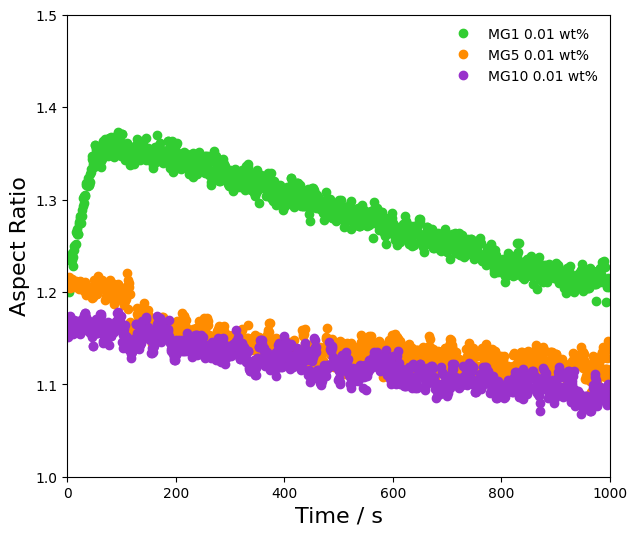

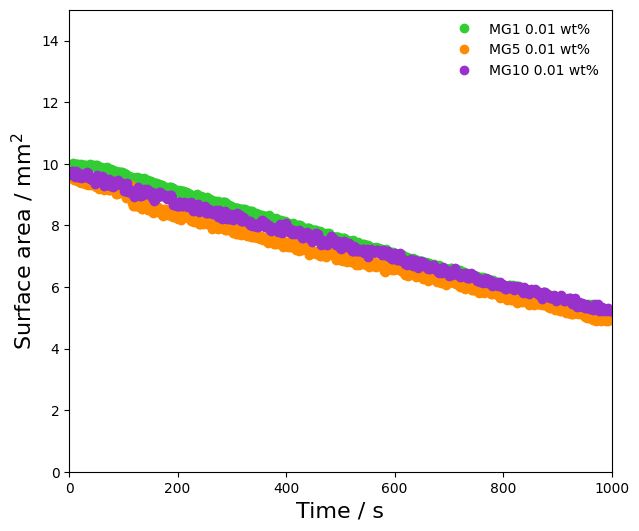

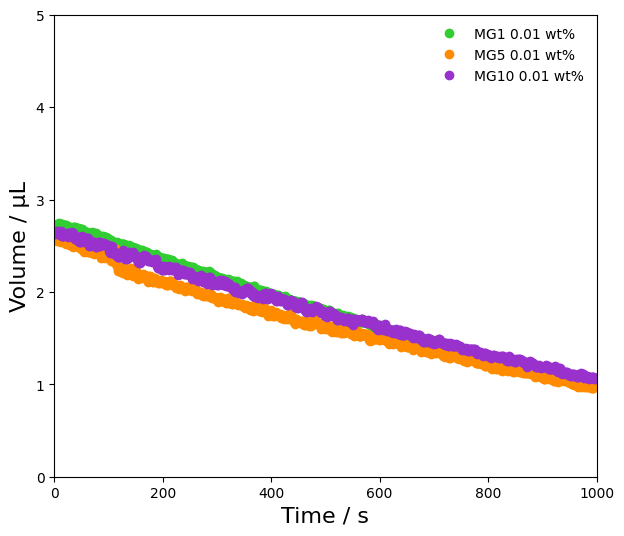

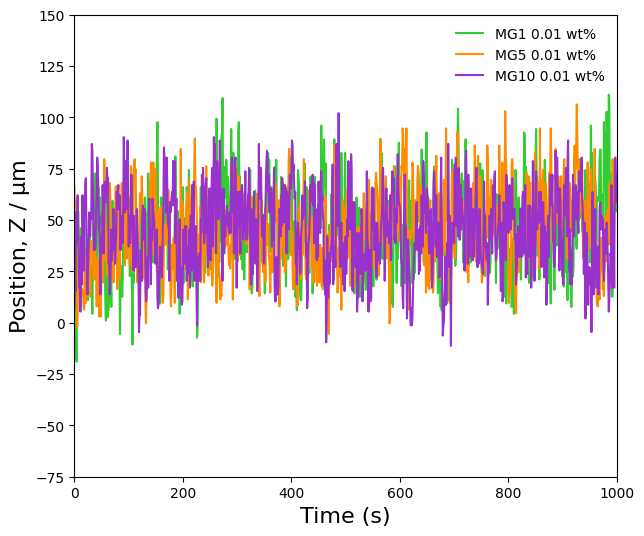

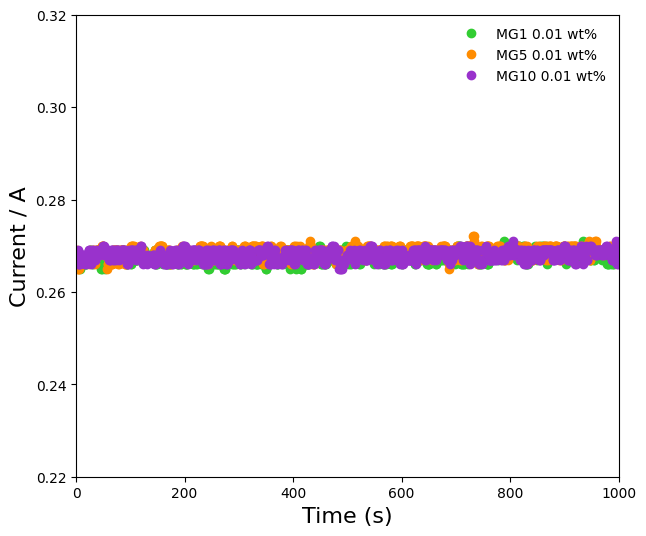

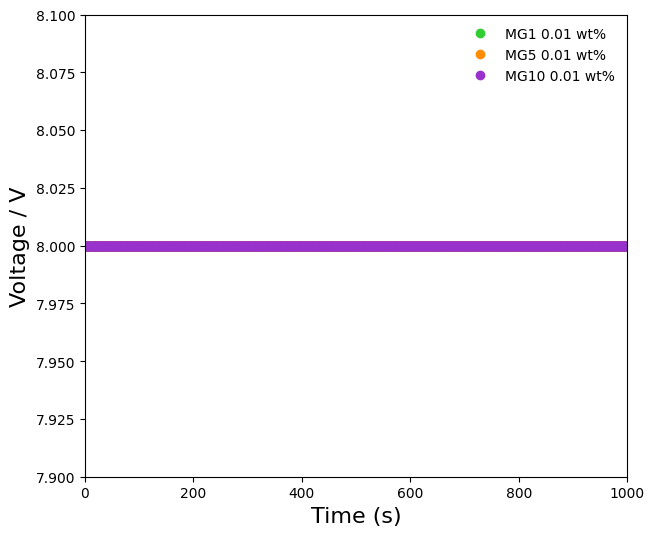

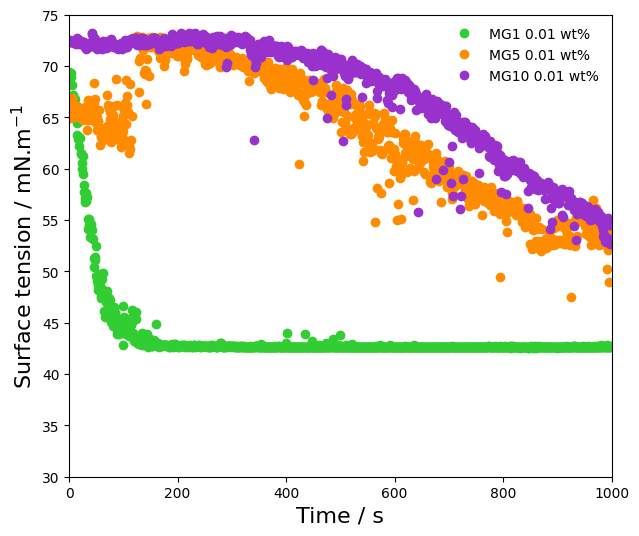

In [ ]:
######### Concentration: 0.01 wt% ###########
path_save =str('/content/drive/My Drive/Atieh_levitation/Processed_with_predicted_ST/after_retraining/Figures/')
savefig = True

selected = [0, 35, 23]
microgel = ['MG1', 'MG5', 'MG10']
conc = filenames[0].split('/')[8].split('_')[2]
labels = ['MG1 0.01 wt%', 'MG5 0.01 wt%', 'MG10 0.01 wt%']

colors = ['limegreen', 'darkorange', 'darkorchid']

plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, 1/data[i, microgel[j]].AR, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s',  fontsize = 16)
plt.ylabel('Aspect Ratio',  fontsize = 16)
plt.ylim(1,1.5)
plt.xlim(0,1000)
if savefig == True:
  plt.savefig(path_save+'Final_AR_vs_time_001wtp_8V.svg')
  plt.savefig(path_save+'Final_AR_vs_time_001wtp_8V.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].surface_area, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s',  fontsize = 16)
plt.ylabel('Surface area / mm$^2$',fontsize = 16)
plt.ylim(0,15)
plt.xlim(0,1000)
if savefig == True:
  plt.savefig(path_save+'Final_SA_vs_time_001wtp_8V.svg')
  plt.savefig(path_save+'Final_SA_vs_time_001wtp_8V.png')

plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].volume, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s',  fontsize = 16)
plt.ylabel('Volume / μL', fontsize = 16)
plt.ylim(0,5)
plt.xlim(0,1000)
if savefig == True:
  plt.savefig(path_save+'Final_volume_vs_time_001wtp_8V.svg')
  plt.savefig(path_save+'Final_volume_vs_time_001wtp_8V.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].centred_z*1000, color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Position, Z / μm',fontsize = 16)
plt.ylim(-75, 150)
plt.xlim(0,1000)
if savefig == True:
  plt.savefig(path_save+'Final_position_vs_time_001wtp_8V.svg')
  plt.savefig(path_save+'Final_position_vs_time_001wtp_8V.png')



plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].current, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Current / A',fontsize = 16)
plt.ylim(0.22,0.32)
plt.xlim(0,1000)
if savefig == True:
  plt.savefig(path_save+'Final_current_vs_time_001wtp_8V.svg')
  plt.savefig(path_save+'Final_current_vs_time_001wtp_8V.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].volt, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Voltage / V',fontsize = 16)
plt.ylim(7.9, 8.1)
plt.xlim(0,1000)
if savefig == True:
  plt.savefig(path_save+'Final_voltage_vs_time_001wtp_8V.svg')
  plt.savefig(path_save+'Final_voltage_vs_time_001wtp_8V.png')



plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].ST_pred, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s', fontsize = 16)
plt.ylabel('Surface tension / mN.m$^{-1}$', fontsize = 16)
plt.ylim(30,75)
plt.xlim(0,1000)
if savefig == True:
  plt.savefig(path_save+'Final_ST_vs_time_001wtp_8V.svg')
  plt.savefig(path_save+'Final_ST_vs_time_001wtp_8V.png')

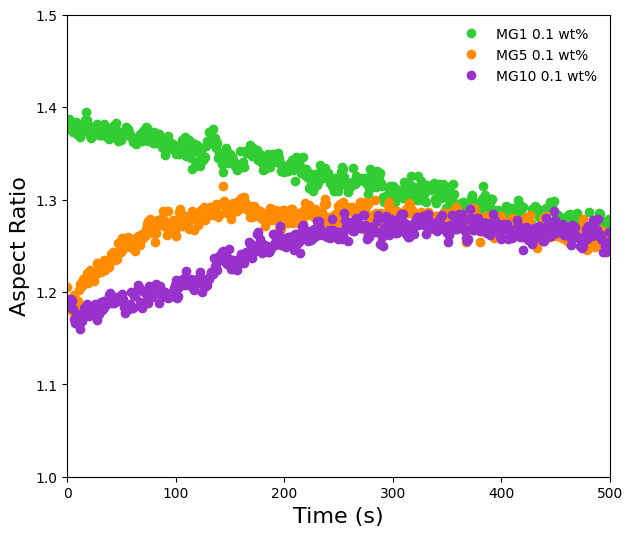

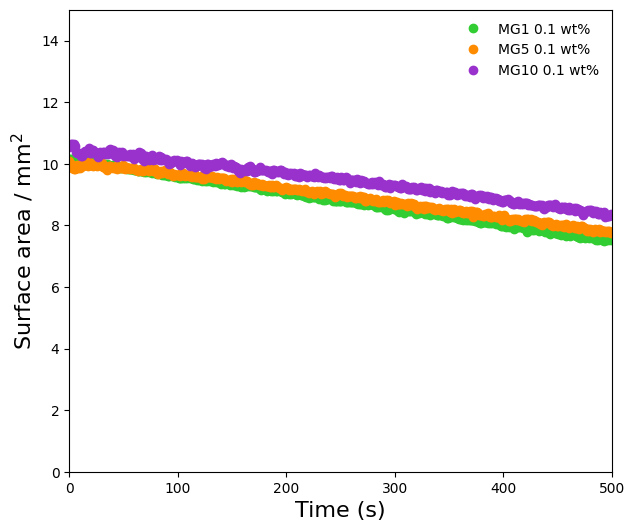

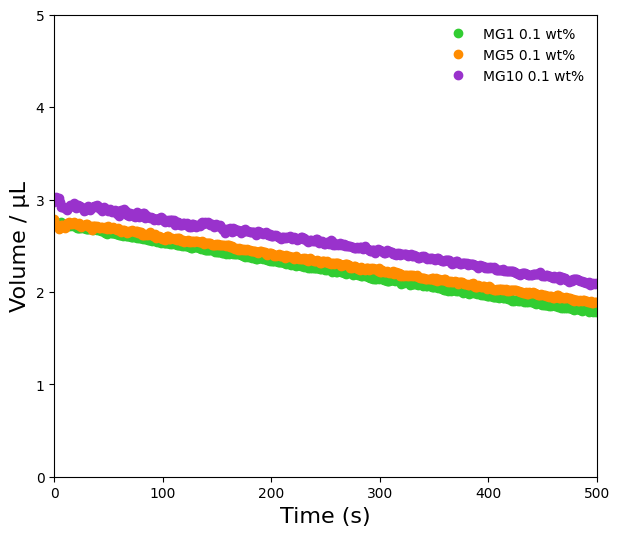

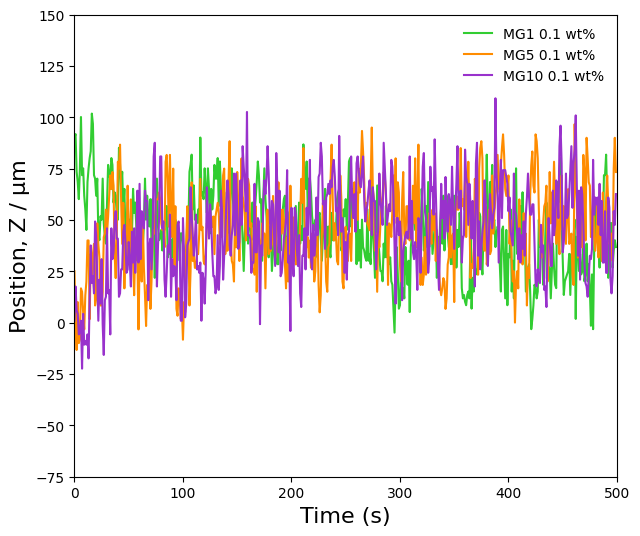

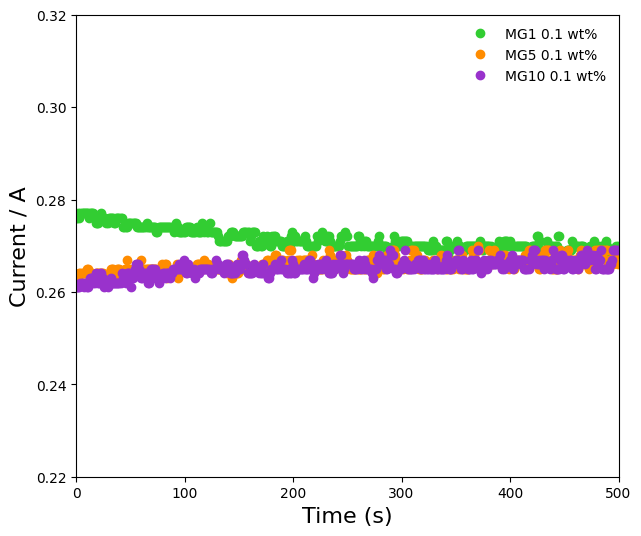

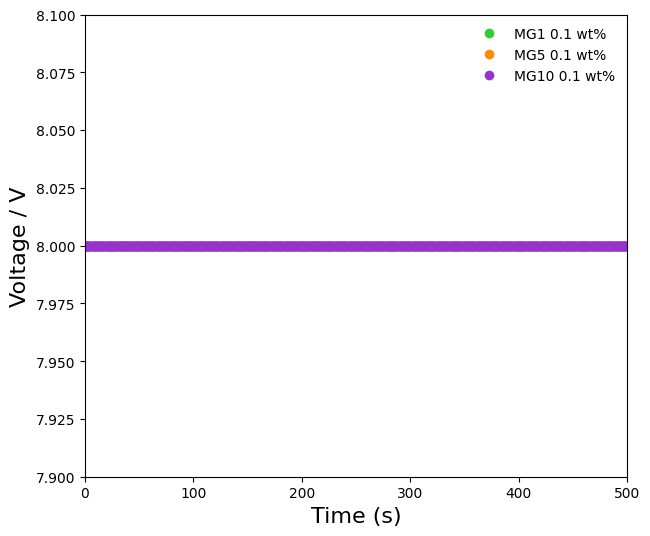

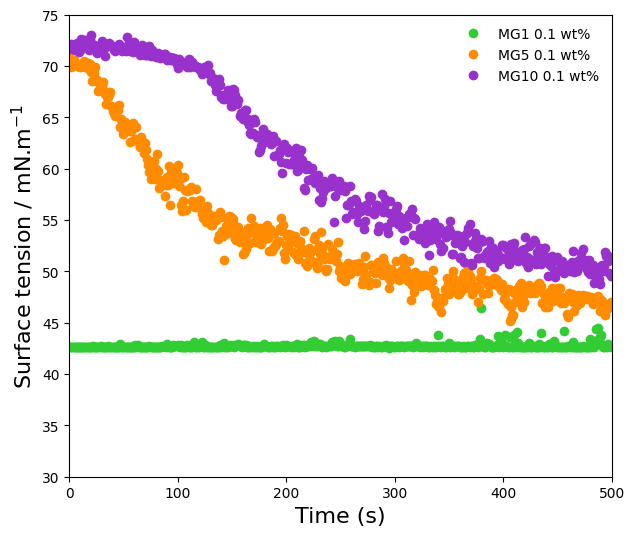

In [ ]:
######### Concentration: 0.1 wt% ###########

selected = [6, 40, 29]
microgel = ['MG1', 'MG5', 'MG10']
conc = filenames[0].split('/')[8].split('_')[2]
labels = ['MG1 0.1 wt%', 'MG5 0.1 wt%', 'MG10 0.1 wt%']

plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, 1/data[i, microgel[j]].AR, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)', fontsize = 16)
plt.ylabel('Aspect Ratio', fontsize = 16)
plt.ylim(1,1.5)
plt.xlim(0,500)
if savefig == True:
  plt.savefig(path_save+'Final_AR_vs_time_01wtp_8V.svg')
  plt.savefig(path_save+'Final_AR_vs_time_01wtp_8V.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].surface_area, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)', fontsize = 16)
plt.ylabel('Surface area / mm$^2$', fontsize = 16)
plt.ylim(0,15)
plt.xlim(0,500)
if savefig == True:
  plt.savefig(path_save+'Final_SA_vs_time_01wtp_8V.svg')
  plt.savefig(path_save+'Final_SA_vs_time_01wtp_8V.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].volume, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Volume / μL',fontsize = 16)
plt.ylim(0,5)
plt.xlim(0,500)
if savefig == True:
  plt.savefig(path_save+'Final_volume_vs_time_01wtp_8V.svg')
  plt.savefig(path_save+'Final_volume_vs_time_01wtp_8V.png')



plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].centred_z*1000, color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Position, Z / μm',fontsize = 16)
plt.ylim(-75, 150)
plt.xlim(0,500)
if savefig == True:
  plt.savefig(path_save+'Final_position_vs_time_01wtp_8V.svg')
  plt.savefig(path_save+'Final_position_vs_time_01wtp_8V.png')



plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].current, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Current / A',fontsize = 16)
plt.ylim(0.22,0.32)
plt.xlim(0,500)
if savefig == True:
  plt.savefig(path_save+'Final_current_vs_time_01wtp_8V.svg')
  plt.savefig(path_save+'Final_current_vs_time_01wtp_8V.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].volt, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Voltage / V',fontsize = 16)
plt.ylim(7.9, 8.1)
plt.xlim(0,500)
if savefig == True:
  plt.savefig(path_save+'Final_voltage_vs_time_01wtp_8V.svg')
  plt.savefig(path_save+'Final_voltage_vs_time_01wtp_8V.png')



plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].ST_pred, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)', fontsize = 16) #fontweight='bold',
plt.ylabel('Surface tension / mN.m$^{-1}$', fontsize = 16)  #fontweight='bold',
plt.ylim(30,75)
plt.xlim(0,500)
if savefig == True:
  plt.savefig(path_save+'Final_ST_vs_time_01wtp_8V.svg')
  plt.savefig(path_save+'Final_ST_vs_time_01wtp_8V.png')

### Plot data under alternating voltage: 8.0 - 11.0 V

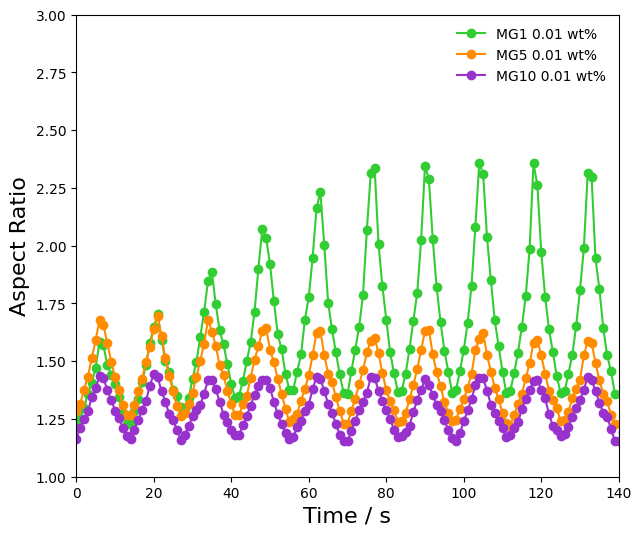

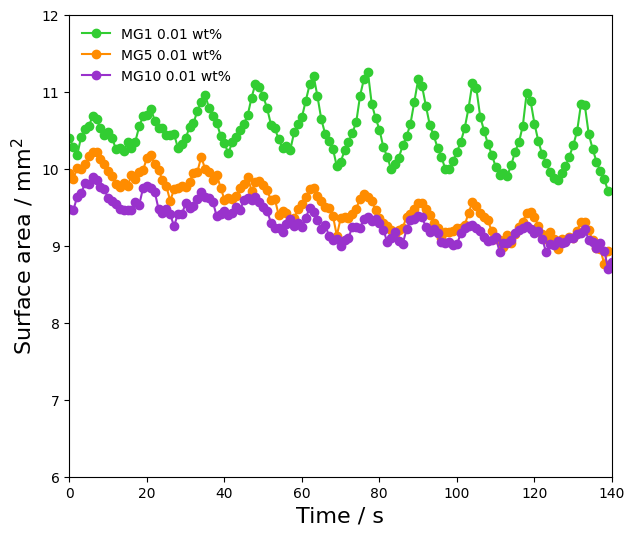

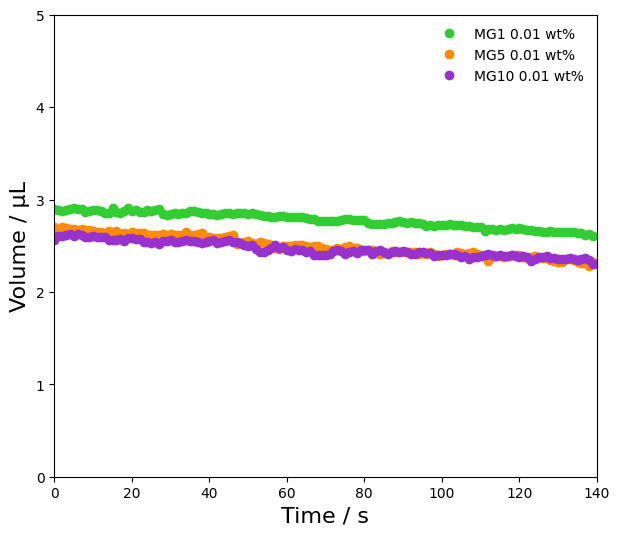

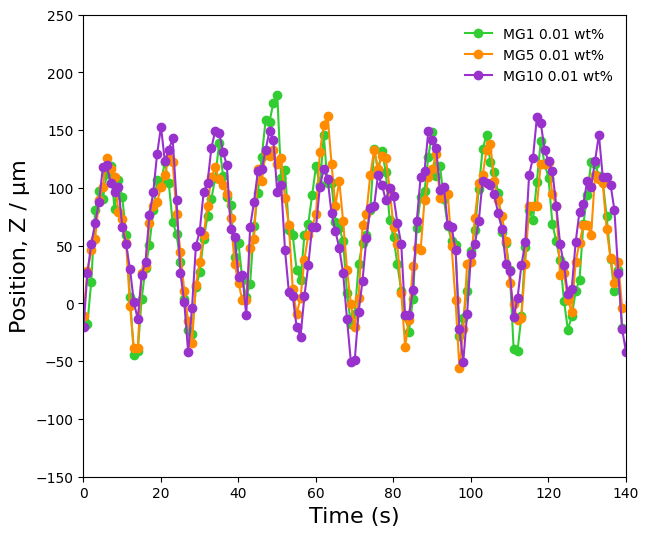

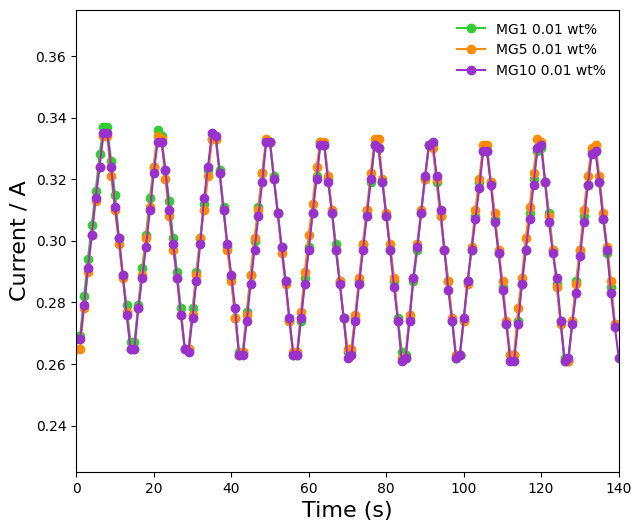

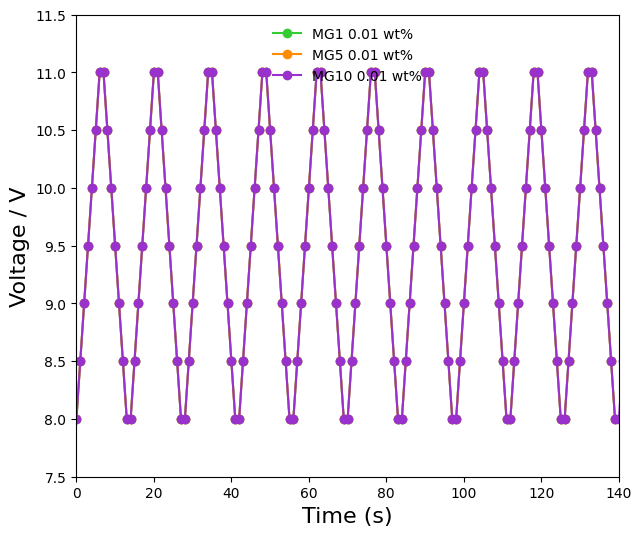

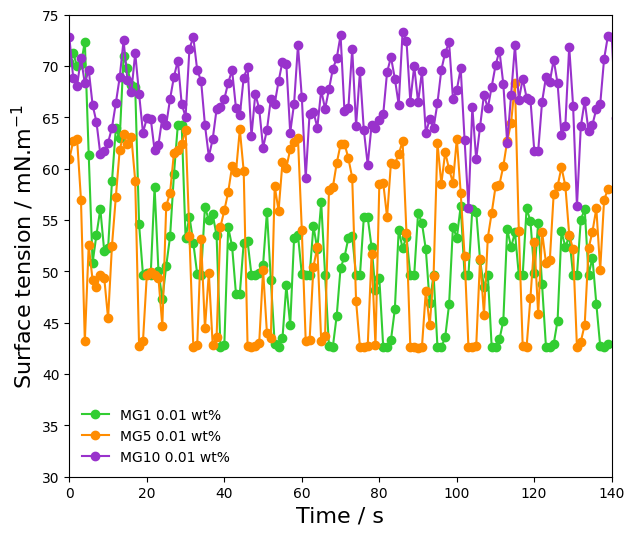

In [ ]:
######### Concentration: 0.01 wt% ###########

savefig = False

selected = [5, 36, 25]
microgel = ['MG1', 'MG5', 'MG10']
conc = filenames[0].split('/')[8].split('_')[2]
labels = ['MG1 0.01 wt%', 'MG5 0.01 wt%', 'MG10 0.01 wt%']

plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, 1/data[i, microgel[j]].AR, '-o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s', fontsize = 16)
plt.ylabel('Aspect Ratio', fontsize = 16)
plt.ylim(1,3)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_AR_vs_time_001wtp_8V-11.svg')
  plt.savefig(path_save+'Final_AR_vs_time_001wtp_8V-11.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].surface_area, '-o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s', fontsize = 16)
plt.ylabel('Surface area / mm$^2$', fontsize = 16)
plt.ylim(6,12)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_SA_vs_time_001wtp_8V-11.svg')
  plt.savefig(path_save+'Final_SA_vs_time_001wtp_8V-11.png')

plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].volume, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s',  fontsize = 16)
plt.ylabel('Volume / μL',fontsize = 16)
plt.ylim(0,5)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_volume_vs_time_001wtp_8V-11.svg')
  plt.savefig(path_save+'Final_volume_vs_time_001wtp_8V-11.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].centred_z*1000, '-o',color=colors[j],  label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Position, Z / μm',fontsize = 16)
plt.ylim(-150, 250)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_position_vs_time_001wtp_8-11V.svg')
  plt.savefig(path_save+'Final_position_vs_time_001wtp_8-11V.png')



plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].current, '-o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Current / A',fontsize = 16)
plt.ylim(0.225,0.375)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_current_vs_time_001wtp_8-11V.svg')
  plt.savefig(path_save+'Final_current_vs_time_001wtp_8-11V.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].volt, '-o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Voltage / V',fontsize = 16)
plt.ylim(7.5, 11.5)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_voltage_vs_time_001wtp_8-11V.svg')
  plt.savefig(path_save+'Final_voltage_vs_time_001wtp_8-11V.png')



# colors = ['#1f77b4', 'darkgoldenrod', 'g']
plt.figure(figsize=(7,6))
j=0
for i in selected:
  x = data[i, microgel[j]].Time
  y = data[i, microgel[j]].ST_pred
  # y_fit_ST = fit_oscillation(x,y)
  plt.plot(x, y, '-o', color=colors[j], label = labels[j])
  # plt.plot(x, y_fit_ST, '-o', lw=2, label="Fitted curve")
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s', fontsize = 16) #fontweight='bold',
plt.ylabel('Surface tension / mN.m$^{-1}$', fontsize = 16)  #fontweight='bold',
plt.ylim(30,75)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_ST_vs_time_001wtp_8-11V.svg')
  plt.savefig(path_save+'Final_ST_vs_time_001wtp_8-11V.png')


In [ ]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import detrend

def fit_shifted_oscillation(t, y, omega=None, detrend_order=1):
    """
    Fit oscillation with drifting baseline. Amplitude may change slowly,
    but frequency ω is estimated separately and fixed.

    Parameters
    ----------
    t : array
        Time (s).
    y : array
        Signal values.
    omega : float or None
        Oscillation angular frequency (rad/s). If None, estimated via FFT.
    detrend_order : int
        Polynomial order for detrending before FFT (0=mean, 1=linear, etc.).

    Returns
    -------
    popt : dict
        Best-fit parameters {"A","phi","C0","C1","omega"}.
    yfit : array
        Fitted signal at t.
    """
    t = np.asarray(t)
    y = np.asarray(y)

    # ---- detrend for frequency estimation ----
    if omega is None:
        if detrend_order == 0:
            y_detr = y - np.mean(y)
        else:
            y_detr = detrend(y, type="linear")
        dt = np.mean(np.diff(t))
        freqs = np.fft.rfftfreq(len(y), dt)
        Y = np.fft.rfft(y_detr * np.hanning(len(y_detr)))
        idx = np.argmax(np.abs(Y[1:])) + 1
        omega = 2*np.pi*freqs[idx]

    # ---- model with fixed omega ----
    def oscillation_model_fixed_omega(tt, A, phi, C0, C1, omega):
        return A * np.cos(omega*tt + phi) + (C0 + C1*tt)

    # ---- parameter guesses ----
    A_guess = 0.5*(np.max(y)-np.min(y))
    phi_guess = 0.0
    C0_guess = np.mean(y)
    C1_guess = (y[-1]-y[0])/(t[-1]-t[0])  # rough slope

    p0 = [A_guess, phi_guess, C0_guess, C1_guess]

    # wrapper with fixed ω
    def model_wrapped(tt, A, phi, C0, C1):
        return oscillation_model_fixed_omega(tt, A, phi, C0, C1, omega)

    popt, _ = curve_fit(model_wrapped, t, y, p0=p0, maxfev=20000)
    yfit = model_wrapped(t, *popt)

    return {"A": popt[0], "phi": popt[1],
            "C0": popt[2], "C1": popt[3],
            "omega": omega}, yfit

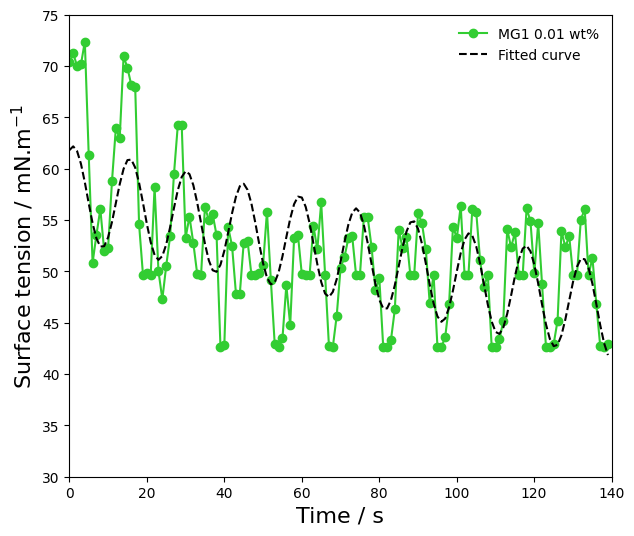

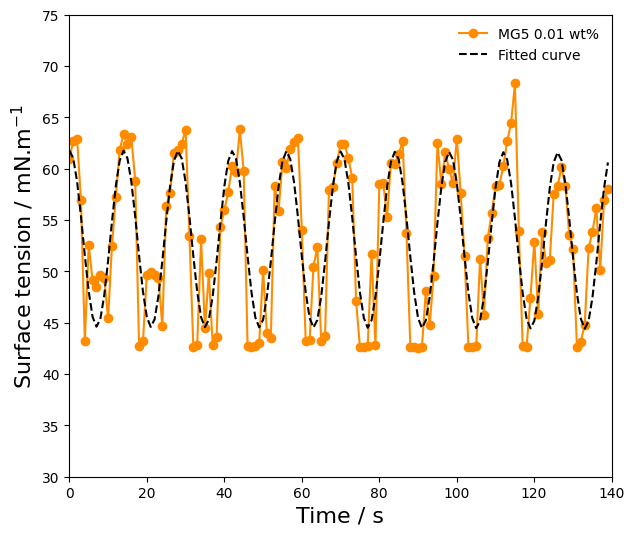

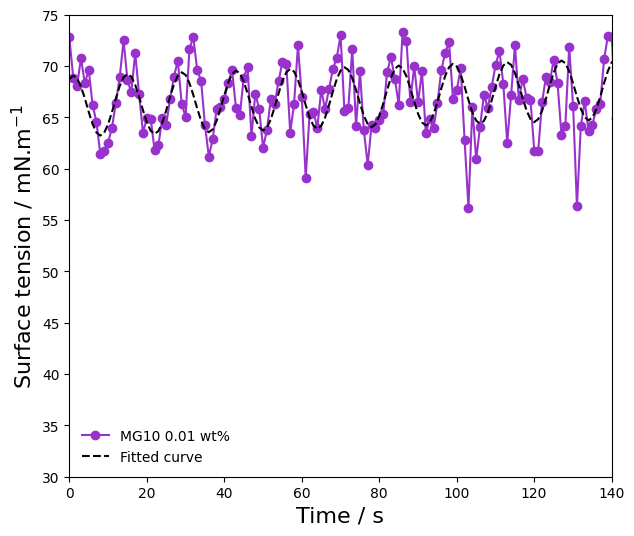

In [ ]:
#### Fitting the surface tension measurements

selected = [5, 36, 25]
microgel = ['MG1', 'MG5', 'MG10']
conc = filenames[0].split('/')[8].split('_')[2]
labels = ['MG1 0.01 wt%', 'MG5 0.01 wt%', 'MG10 0.01 wt%']
ST_fit = {}

colors = ['limegreen', 'darkorange', 'darkorchid']

j=0
for i in selected:
  plt.figure(figsize=(7,6))
  x = data[i, microgel[j]].Time
  y = data[i, microgel[j]].ST_pred
  if j==0:
    p0, y_fit_ST = fit_shifted_oscillation(x,y,omega=0.43)
    ST_fit[microgel[j]] = y_fit_ST
    plt.plot(x, y, '-o', color=colors[j], label = labels[j])
    plt.plot(x, y_fit_ST, '--k', lw=1.5, label="Fitted curve")
  else:
    p0, y_fit_ST = fit_shifted_oscillation(x,y)
    ST_fit[microgel[j]] = y_fit_ST
    plt.plot(x, y, '-o', color=colors[j], label = labels[j])
    plt.plot(x, y_fit_ST, '--k', lw=1.5, label="Fitted curve")
  plt.legend(frameon=False)
  plt.xlabel('Time / s', fontsize = 16) #fontweight='bold',
  plt.ylabel('Surface tension / mN.m$^{-1}$', fontsize = 16)  #fontweight='bold',
  plt.ylim(30,75)
  plt.xlim(0,140)
  if savefig == True:
    plt.savefig(path_save+'ST-fitted_vs_time_001wtp_8-11V_%s.svg' %microgel[j])
    plt.savefig(path_save+'ST-fitted_vs_time_001wtp_8-11V_%s.png' %microgel[j])
  j=j+1








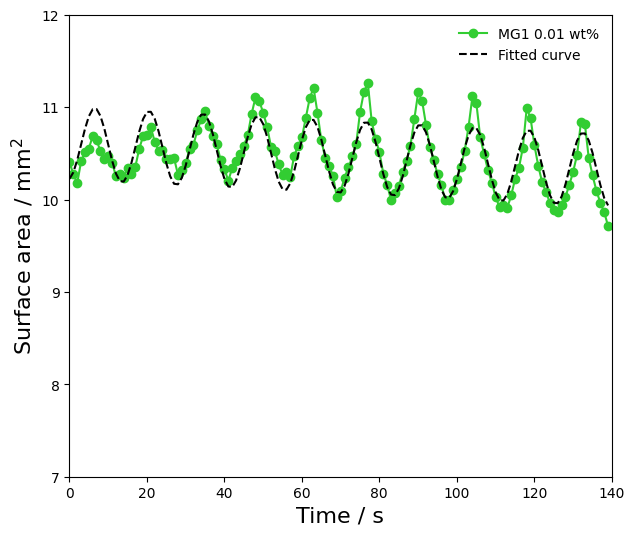

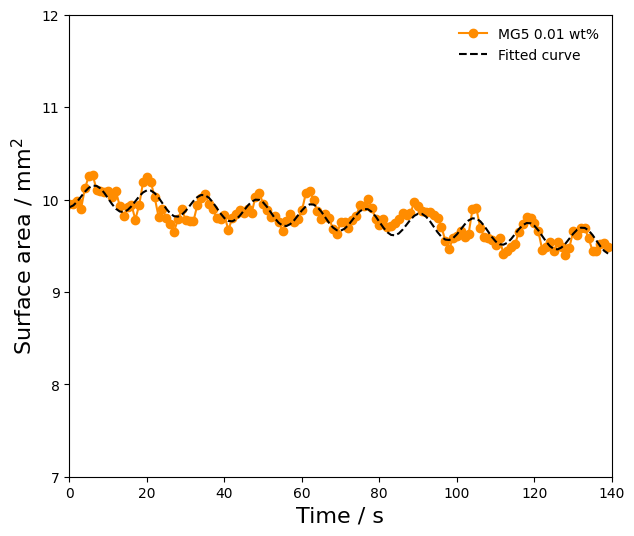

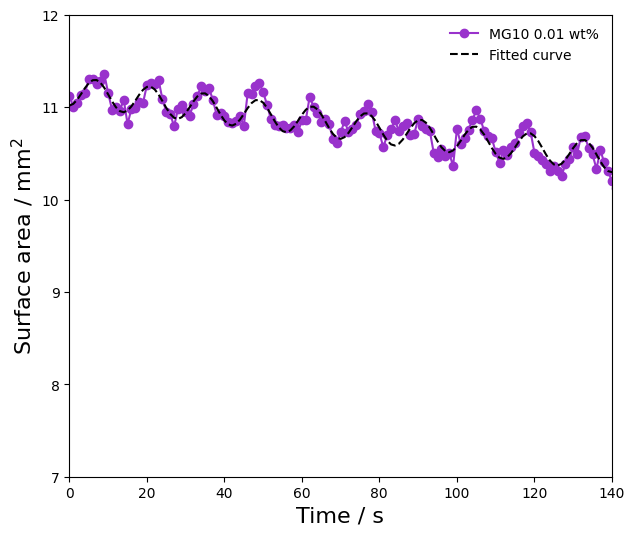

In [ ]:
#### Fitting the surface area measurements

selected = [5, 36, 25]
microgel = ['MG1', 'MG5', 'MG10']
conc = filenames[0].split('/')[8].split('_')[2]
labels = ['MG1 0.01 wt%', 'MG5 0.01 wt%', 'MG10 0.01 wt%']
SA_fit = {}

colors = ['limegreen', 'darkorange', 'darkorchid']

j=0
for i in selected:
  plt.figure(figsize=(7,6))
  x = data[i, microgel[j]].Time
  y = data[i, microgel[j]].surface_area
  # if j==0:
  #   p0, y_fit_SA = fit_shifted_oscillation(x,y,omega=0.43)
  #   SA_fit[microgel[j]] = y_fit_SA
  #   plt.plot(x, y, '-o', color=colors[j], label = labels[j])
  #   plt.plot(x, y_fit_SA, '--k', lw=1.5, label="Fitted curve")
  # else:
  p0, y_fit_SA = fit_shifted_oscillation(x,y)
  SA_fit[microgel[j]] = y_fit_SA
  plt.plot(x, y, '-o', color=colors[j], label = labels[j])
  plt.plot(x, y_fit_SA, '--k', lw=1.5, label="Fitted curve")
  plt.legend(frameon=False)
  plt.xlabel('Time / s', fontsize = 16) #fontweight='bold',
  plt.ylabel('Surface area / mm$^{2}$', fontsize = 16)  #fontweight='bold',
  plt.ylim(7,12)
  plt.xlim(0,140)
  if savefig == True:
    plt.savefig(path_save+'SA-fitted_vs_time_001wtp_8-11V_%s.svg' %microgel[j])
    plt.savefig(path_save+'SA-fitted_vs_time_001wtp_8-11V_%s.png' %microgel[j])
  j=j+1








In [ ]:

MG = ['MG1', 'MG5', 'MG10']
path_save = str('/content/drive/My Drive/Atieh_levitation/Processed_with_predicted_ST/after_retraining/fitted_SA_ST/')

for i in range(3):
  test = pd.DataFrame()
  test['fitted_ST'] = ST_fit[MG[i]]
  test['fitted_SA'] = SA_fit[MG[i]]
  test.to_csv(path_save+MG[i]+'_0.010wtp_Vi_8.0_Vf_11.0_rate_0.500Hz_best.csv', sep='\t')


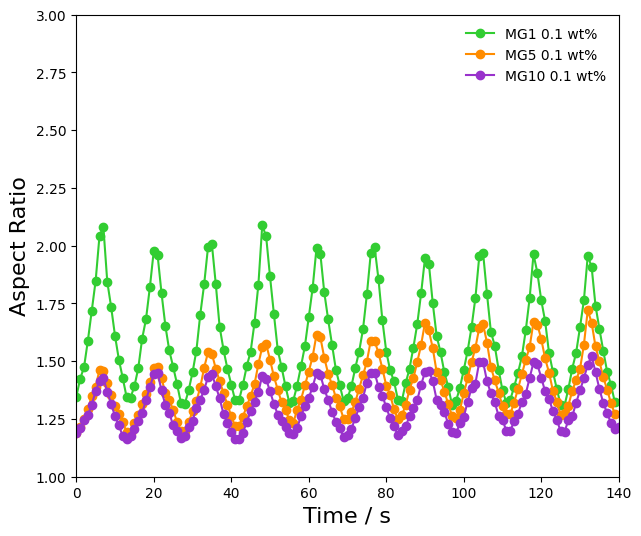

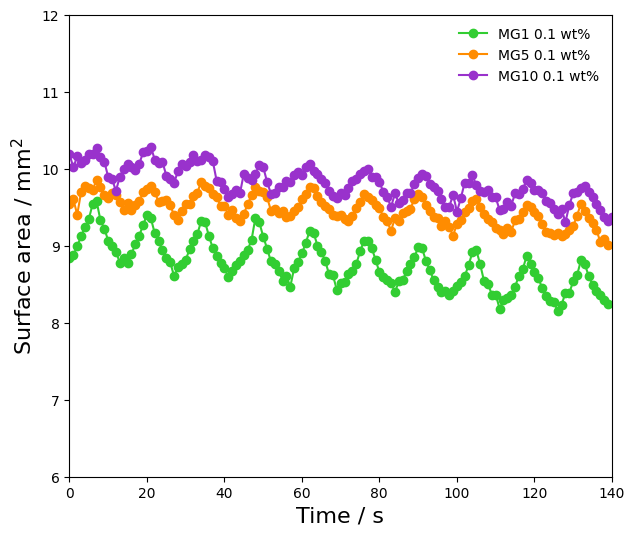

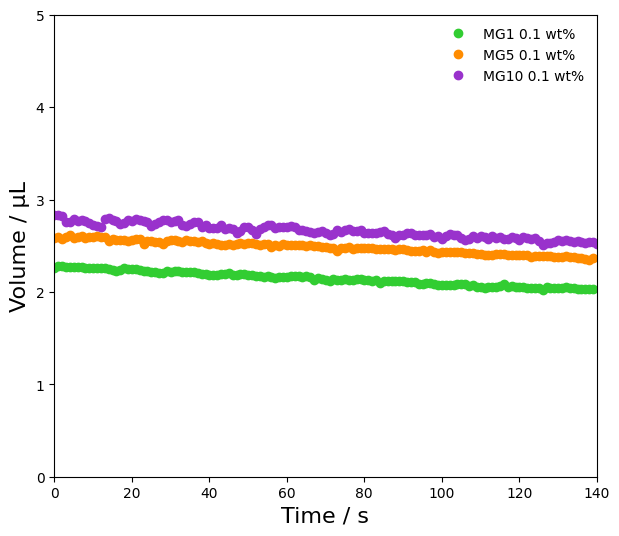

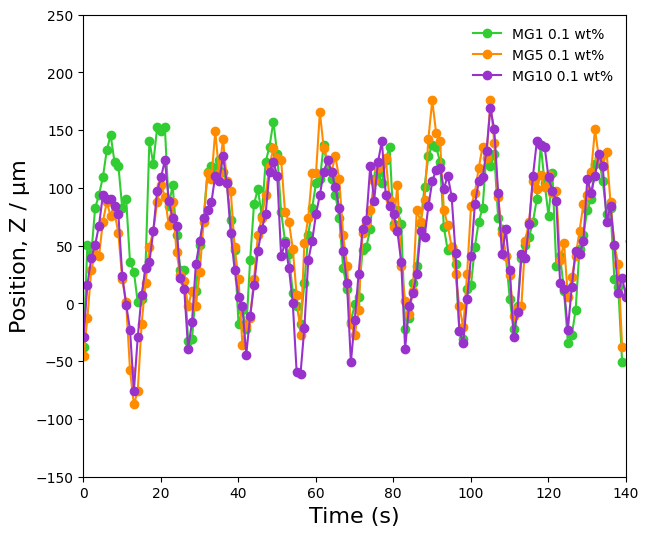

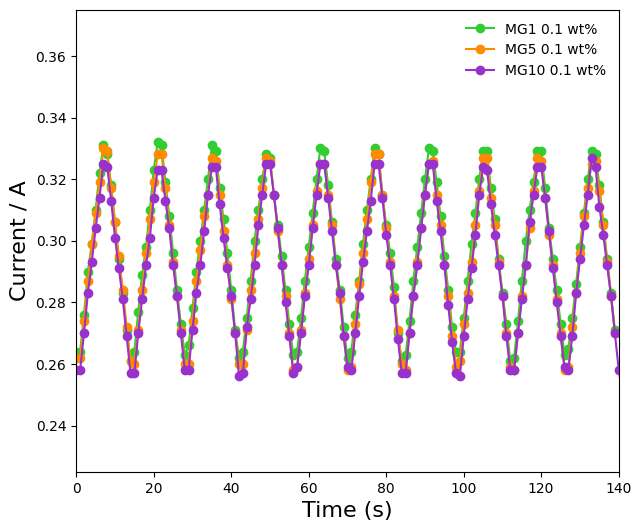

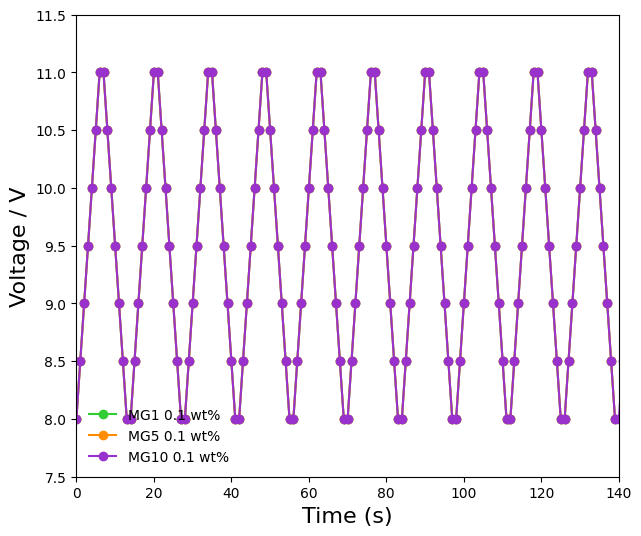

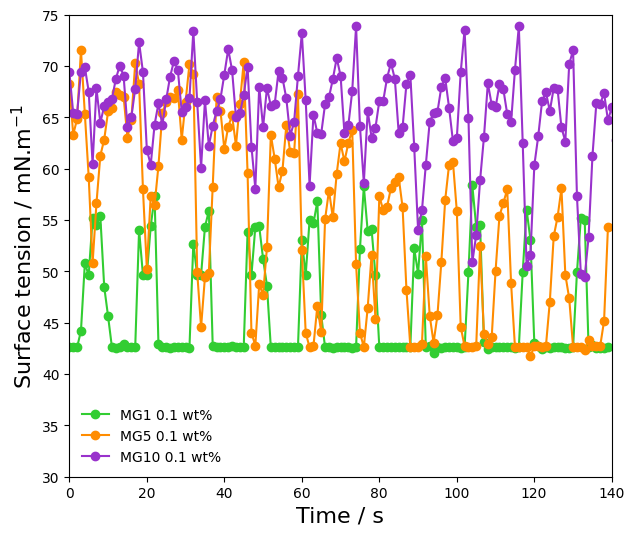

In [ ]:
######### Concentration: 0.1 wt% ###########

selected = [10, 43, 32]
microgel = ['MG1', 'MG5', 'MG10']
conc = filenames[0].split('/')[8].split('_')[2]
labels = ['MG1 0.1 wt%', 'MG5 0.1 wt%', 'MG10 0.1 wt%']

plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, 1/data[i, microgel[j]].AR, '-o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s', fontsize = 16)
plt.ylabel('Aspect Ratio', fontsize = 16)
plt.ylim(1,3)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_AR_vs_time_01wtp_8V-11.svg')
  plt.savefig(path_save+'Final_AR_vs_time_01wtp_8V-11.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].surface_area, '-o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s', fontsize = 16)
plt.ylabel('Surface area / mm$^2$', fontsize = 16)
plt.ylim(6,12)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_SA_vs_time_01wtp_8V-11.svg')
  plt.savefig(path_save+'Final_SA_vs_time_01wtp_8V-11.png')

plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].volume, 'o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s',  fontsize = 16)
plt.ylabel('Volume / μL',fontsize = 16)
plt.ylim(0,5)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_volume_vs_time_01wtp_8V-11.svg')
  plt.savefig(path_save+'Final_volume_vs_time_01wtp_8V-11.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].centred_z*1000, '-o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Position, Z / μm',fontsize = 16)
plt.ylim(-150, 250)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_position_vs_time_01wtp_8-11V.svg')
  plt.savefig(path_save+'Final_position_vs_time_01wtp_8-11V.png')



plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].current, '-o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Current / A',fontsize = 16)
plt.ylim(0.225,0.375)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_current_vs_time_01wtp_8-11V.svg')
  plt.savefig(path_save+'Final_current_vs_time_01wtp_8-11V.png')


plt.figure(figsize=(7,6))
j=0
for i in selected:
  plt.plot(data[i, microgel[j]].Time, data[i, microgel[j]].volt, '-o', color=colors[j], label = labels[j])
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time (s)',  fontsize = 16)
plt.ylabel('Voltage / V',fontsize = 16)
plt.ylim(7.5, 11.5)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_voltage_vs_time_01wtp_8-11V.svg')
  plt.savefig(path_save+'Final_voltage_vs_time_01wtp_8-11V.png')



# colors = ['#1f77b4', 'darkgoldenrod', 'g']
plt.figure(figsize=(7,6))
j=0
for i in selected:
  x = data[i, microgel[j]].Time
  y = data[i, microgel[j]].ST_pred
  # y_fit_ST = fit_oscillation(x,y)
  plt.plot(x, y, '-o', color=colors[j], label = labels[j])
  # plt.plot(x, y_fit_ST, '-o', lw=2, label="Fitted curve")
  j=j+1
plt.legend(frameon=False)
plt.xlabel('Time / s', fontsize = 16) #fontweight='bold',
plt.ylabel('Surface tension / mN.m$^{-1}$', fontsize = 16)  #fontweight='bold',
plt.ylim(30,75)
plt.xlim(0,140)
if savefig == True:
  plt.savefig(path_save+'Final_ST_vs_time_01wtp_8-11V.svg')
  plt.savefig(path_save+'Final_ST_vs_time_01wtp_8-11V.png')


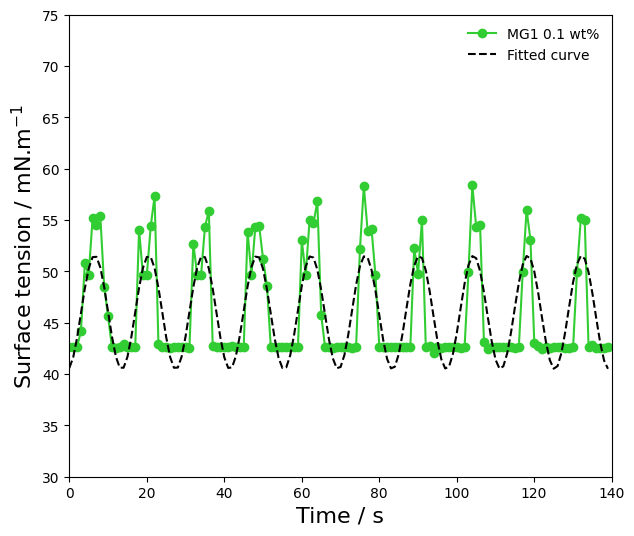

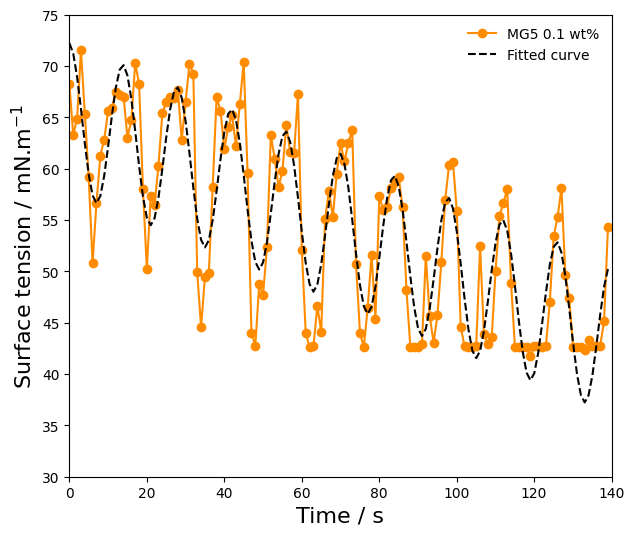

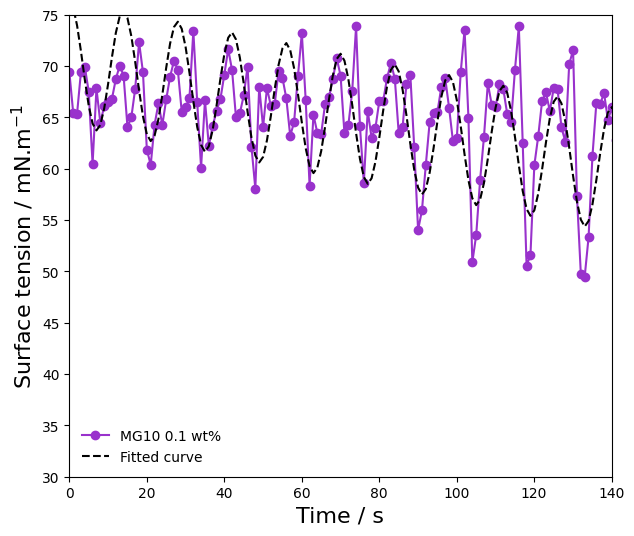

In [ ]:
#### Fitting the surface tension measurements

selected = [10, 43, 32]
microgel = ['MG1', 'MG5', 'MG10']
conc = filenames[0].split('/')[8].split('_')[2]
labels = ['MG1 0.1 wt%', 'MG5 0.1 wt%', 'MG10 0.1 wt%']



colors = ['limegreen', 'darkorange', 'darkorchid']

j=0
for i in selected:
  plt.figure(figsize=(7,6))
  x = data[i, microgel[j]].Time
  y = data[i, microgel[j]].ST_pred
  if j==0:
    y_fit_ST, p0 = fit_oscillation(x,y)
    plt.plot(x, y, '-o', color=colors[j], label = labels[j])
    plt.plot(x, y_fit_ST, '--k', lw=1.5, label="Fitted curve")
  else:
    p0, y_fit_ST = fit_shifted_oscillation(x,y)
    plt.plot(x, y, '-o', color=colors[j], label = labels[j])
    plt.plot(x, y_fit_ST, '--k', lw=1.5, label="Fitted curve")
  plt.legend(frameon=False)
  plt.xlabel('Time / s', fontsize = 16) #fontweight='bold',
  plt.ylabel('Surface tension / mN.m$^{-1}$', fontsize = 16)  #fontweight='bold',
  plt.ylim(30,75)
  plt.xlim(0,140)
  if savefig == True:
    plt.savefig(path_save+'ST-fitted_vs_time_01wtp_8-11V_%s.svg' %microgel[j])
    plt.savefig(path_save+'ST-fitted_vs_time_01wtp_8-11V_%s.png' %microgel[j])
  j=j+1








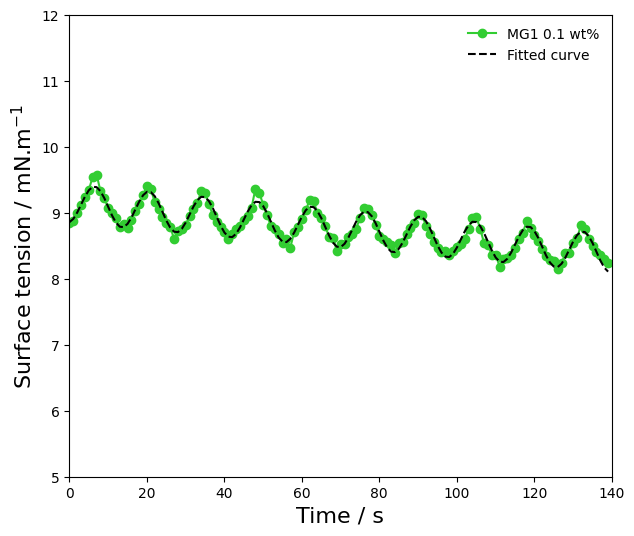

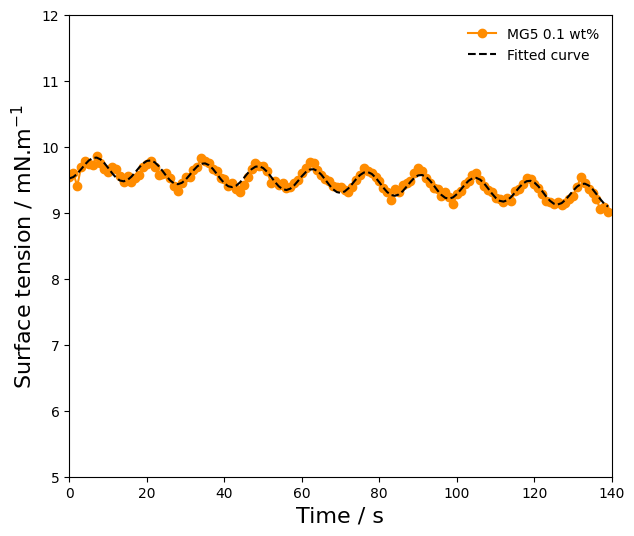

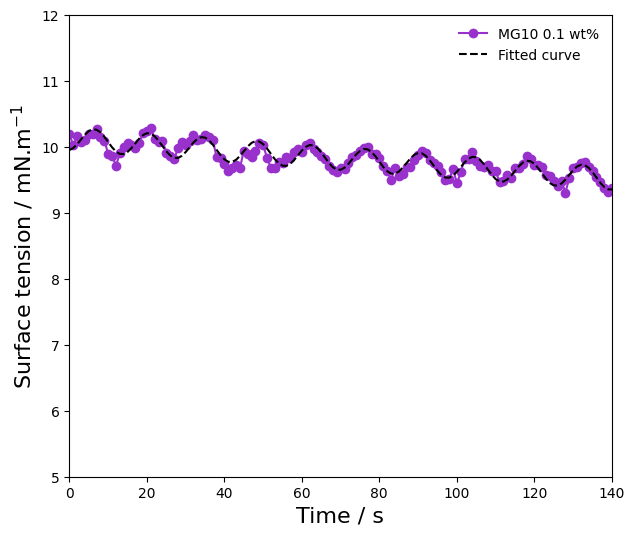

In [ ]:
#### Fitting the surface tension measurements

selected = [10, 43, 32]
microgel = ['MG1', 'MG5', 'MG10']
conc = filenames[0].split('/')[8].split('_')[2]
labels = ['MG1 0.1 wt%', 'MG5 0.1 wt%', 'MG10 0.1 wt%']
SA_fit = {}

colors = ['limegreen', 'darkorange', 'darkorchid']

j=0
for i in selected:
  plt.figure(figsize=(7,6))
  x = data[i, microgel[j]].Time
  y = data[i, microgel[j]].surface_area
  p0, y_fit_SA = fit_shifted_oscillation(x,y)
  SA_fit[microgel[j]] = y_fit_SA
  plt.plot(x, y, '-o', color=colors[j], label = labels[j])
  plt.plot(x, y_fit_SA, '--k', lw=1.5, label="Fitted curve")
  plt.legend(frameon=False)
  plt.xlabel('Time / s', fontsize = 16) #fontweight='bold',
  plt.ylabel('Surface tension / mN.m$^{-1}$', fontsize = 16)  #fontweight='bold',
  plt.ylim(5,12)
  plt.xlim(0,140)
  if savefig == True:
    plt.savefig(path_save+'ST-fitted_vs_time_01wtp_8-11V_%s.svg' %microgel[j])
    plt.savefig(path_save+'ST-fitted_vs_time_01wtp_8-11V_%s.png' %microgel[j])
  j=j+1



In [ ]:

MG = ['MG1', 'MG5', 'MG10']
path_save = str('/content/drive/My Drive/Atieh_levitation/Processed_with_predicted_ST/after_retraining/fitted_SA_ST/')


for i in range(3):
  test = pd.DataFrame()
  test['fitted_ST'] = ST_fit[MG[i]]
  test['fitted_SA'] = SA_fit[MG[i]]
  test.to_csv(path_save+MG[i]+'_0.10wtp_Vi_8.0_Vf_11.0_rate_0.500Hz_best.csv', sep='\t')


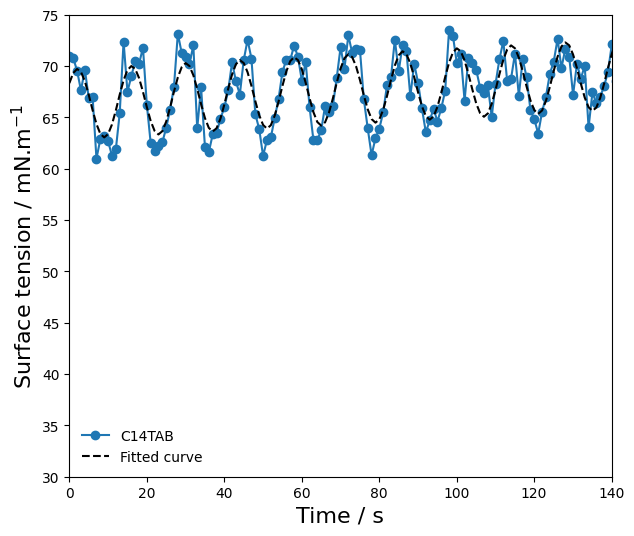

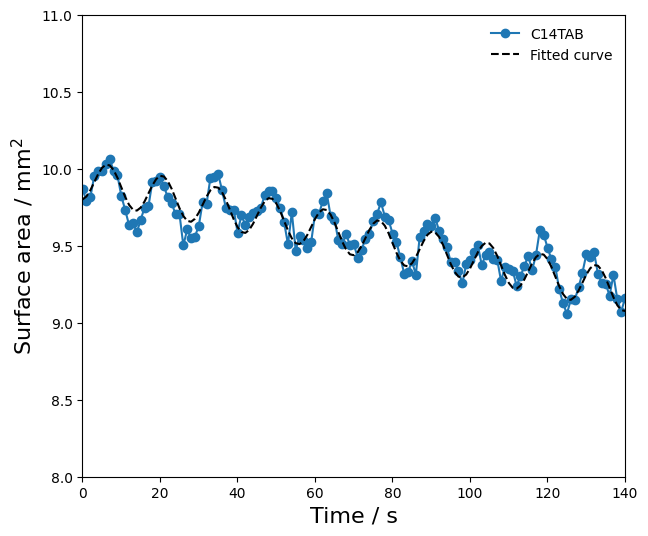

In [ ]:

### Fitting C14TAB


plt.figure(figsize=(7,6))
x = data[20, 'C14TAB'].Time
y = data[20, 'C14TAB'].ST_pred
p0, y_fit_ST = fit_shifted_oscillation(x,y)
ST_fit['C14TAB'] = y_fit_ST
plt.plot(x, y, '-o', label = 'C14TAB')
plt.plot(x, y_fit_ST, '--k', lw=1.5, label="Fitted curve")
plt.legend(frameon=False)
plt.xlabel('Time / s', fontsize = 16) #fontweight='bold',
plt.ylabel('Surface tension / mN.m$^{-1}$', fontsize = 16)  #fontweight='bold',
plt.ylim(30,75)
plt.xlim(0,140)



plt.figure(figsize=(7,6))
x = data[20, 'C14TAB'].Time
y = data[20, 'C14TAB'].surface_area
p0, y_fit_SA = fit_shifted_oscillation(x,y)
SA_fit['C14TAB'] = y_fit_SA
plt.plot(x, y, '-o', label = 'C14TAB')
plt.plot(x, y_fit_SA, '--k', lw=1.5, label="Fitted curve")
plt.legend(frameon=False)
plt.xlabel('Time / s', fontsize = 16) #fontweight='bold',
plt.ylabel('Surface area / mm$^{2}$', fontsize = 16)  #fontweight='bold',
plt.ylim(8,11)
plt.xlim(0,140)


test = pd.DataFrame()
test['fitted_ST'] = ST_fit['C14TAB']
test['fitted_SA'] = SA_fit['C14TAB']

test.to_csv(path_save+'C14TAB_Vi_8.0_Vf_11.0_rate_0.500Hz.csv', sep='\t')

